In [1]:
import json
from torch.utils.data.distributed import DistributedSampler
from core.dataset import TrainDataset
from core.prefetch_dataloader import PrefetchDataLoader, CPUPrefetcher
from core.utils import get_blurred_masked_frames
import torch
import os
import numpy as np
import matplotlib.pyplot as plt


os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

config = json.load(open("./configs/train_depthcomp.json"))
config["world_size"] = torch.cuda.device_count()
# config["init_method"] = f"tcp://{get_master_ip()}:{args.port}"
config["distributed"] = True if config["world_size"] > 1 else False

if "local_rank" not in config:
    config["local_rank"] = config["global_rank"] = torch.cuda.device_count()
if torch.cuda.is_available():
    config["device"] = torch.device("cuda:{}".format(config["local_rank"]))
    print("Using ", torch.cuda.get_device_name(0))
else:
    config["device"] = "cpu"
    print("No GPU found, using CPU instead")


train_dataset = TrainDataset(config["train_data_loader"])
train_sampler = None
train_args = config["trainer"]
if config["distributed"]:
    train_sampler = DistributedSampler(
        train_dataset,
        num_replicas=config["world_size"],
        rank=config["global_rank"],
    )

dataloader_args = dict(
    dataset=train_dataset,
    batch_size=train_args["batch_size"] // config["world_size"],
    shuffle=(train_sampler is None),
    num_workers=train_args["num_workers"],
    sampler=train_sampler,
    drop_last=True,
)

train_loader = PrefetchDataLoader(
    train_args["num_prefetch_queue"], **dataloader_args
)
prefetcher = CPUPrefetcher(train_loader)

Using  NVIDIA GeForce RTX 4090


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping i

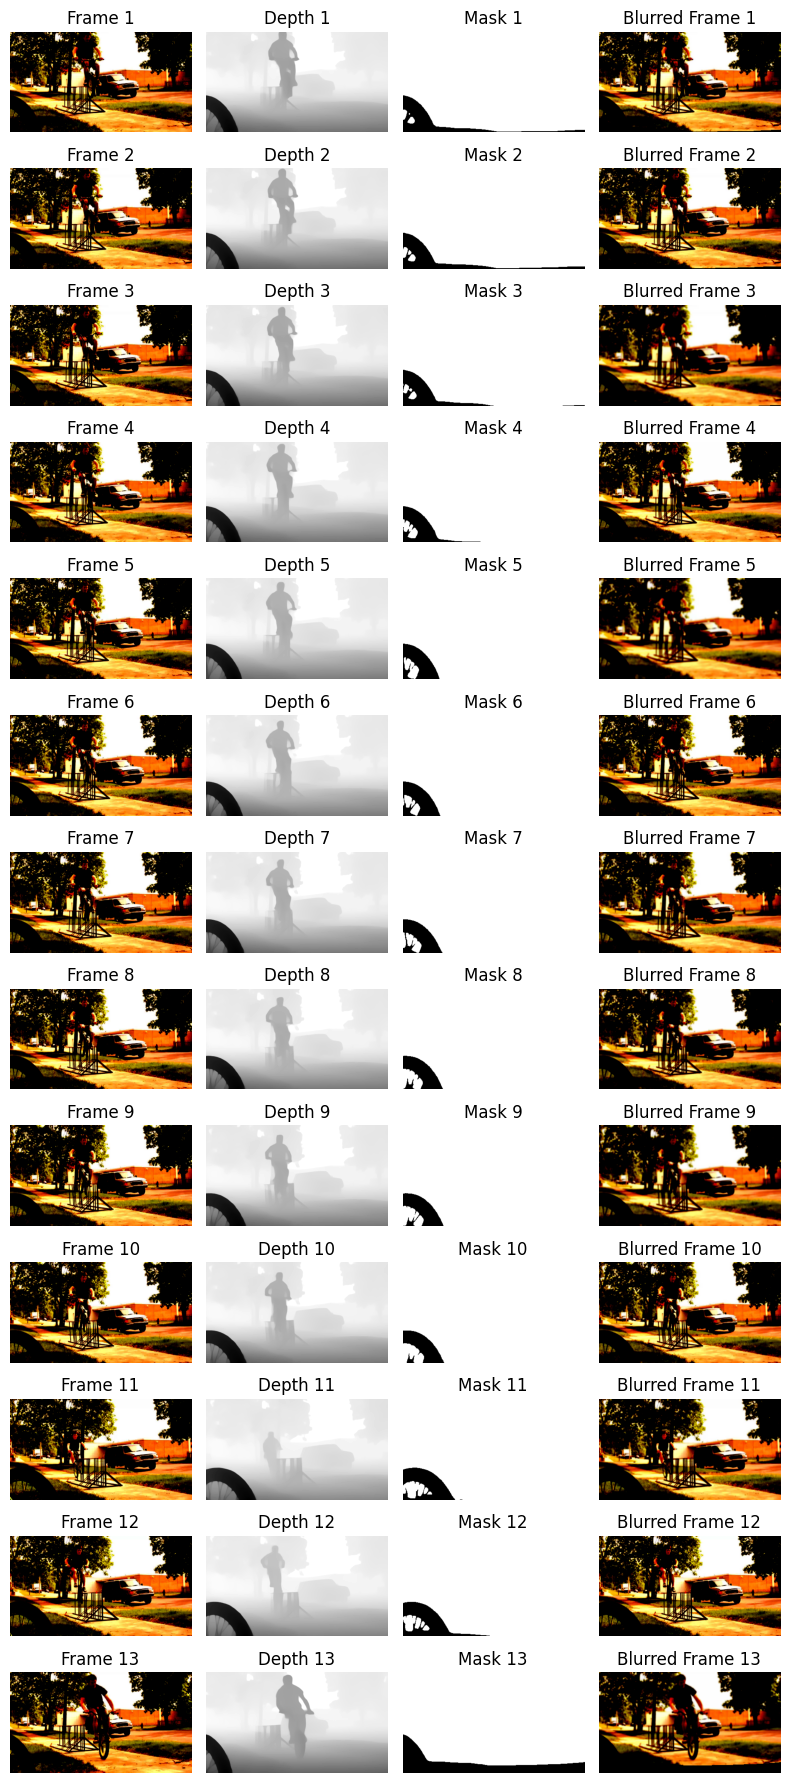

In [37]:
data = prefetcher.next();
frame_tensors, mask_tensors, depth_tensors, flows_f, flows_b, video_name = data
masked_frames = get_blurred_masked_frames(frame_tensors, mask_tensors)

img = 0


fig, axs = plt.subplots(len(frame_tensors[img]), 4, figsize=(8, 18))

for i in range(0,len(frame_tensors[img])):
    
    axs[i, 0].imshow(frame_tensors[img][i].permute(1, 2, 0).numpy())
    axs[i, 0].axis('off')
    axs[i, 0].set_title(f'Frame {i+1}')

    axs[i, 1].imshow(depth_tensors[img][i].squeeze().numpy(), cmap='gray')
    axs[i, 1].axis('off')
    axs[i, 1].set_title(f'Depth {i+1}')

    axs[i, 2].imshow(mask_tensors[img][i].squeeze().numpy(), cmap='gray')
    axs[i, 2].axis('off')
    axs[i, 2].set_title(f'Mask {i+1}')

    axs[i, 3].imshow(masked_frames[img][i].cpu().numpy().transpose(1, 2, 0))
    axs[i, 3].axis('off')
    axs[i, 3].set_title(f'Blurred Frame {i+1}')

plt.tight_layout()
plt.show()


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


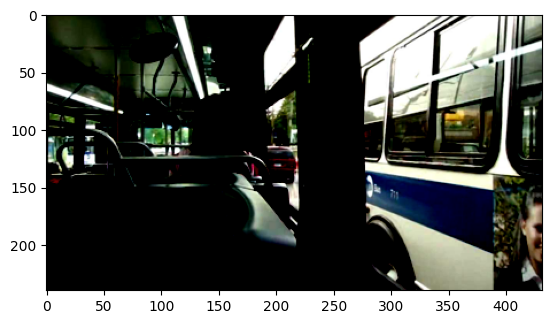

In [4]:
plt.imshow(frame_tensors[1][0].permute(1,2,0).numpy())


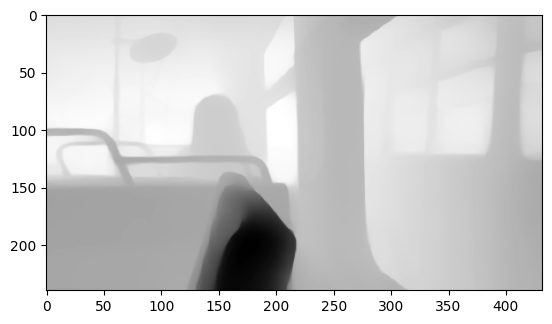

In [5]:
plt.imshow(depth_tensors[1][0].squeeze().numpy(), cmap="gray")

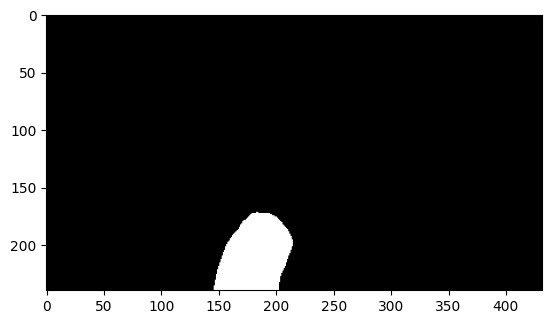

In [6]:
plt.imshow(mask_tensors[1][0].squeeze().numpy(), cmap="gray")

In [7]:
train_dataset.__dict__.keys()

dict_keys(['args', 'depth_root', 'video_root', 'flow_root', 'num_local_frames', 'num_ref_frames', 'size', 'w', 'h', 'load_flow', 'load_depth', 'video_train_dict', 'video_names', 'video_dict', 'frame_dict', '_to_tensors', 'file_client'])

In [8]:
from model.modules.flow_comp_raft import RAFT_bi, FlowLoss, EdgeLoss
from model.canny.canny_filter import Canny


device = torch.device("cuda:0")
train_dataset.fix_raft = RAFT_bi(device=device)
train_dataset.canny = Canny(sigma=(2, 2), low_threshold=0.1, high_threshold=0.2)


frames, masks, depths, flows_f, flows_b, _ = data
frames, masks, depths = frames.to(device), masks.to(device), depths.to(device)
masks, depths = masks.float(), depths.float()

l_t = train_dataset.num_local_frames
b, t, c, h, w = frames.size()
gt_local_frames = frames[:, :l_t, ...]
local_masks = masks[:, :l_t, ...].contiguous()
local_depths = depths[:, :l_t, ...].contiguous()


def get_edges(flows):
    # (b, t, 2, H, W)
    b, t, _, h, w = flows.shape
    flows = flows.view(-1, 2, h, w)
    flows_gray = (flows[:, 0, None] ** 2 + flows[:, 1, None] ** 2) ** 0.5
    if flows_gray.max() < 1:
        flows_gray = flows_gray * 0
    else:
        flows_gray = flows_gray / flows_gray.max()

    magnitude, edges = train_dataset.canny(flows_gray.float())
    edges = edges.view(b, t, 1, h, w)
    return edges

# get gt optical flow
if flows_f[0] == "None" or flows_b[0] == "None":
    gt_flows_bi = train_dataset.fix_raft(gt_local_frames)
else:
    gt_flows_bi = (flows_f.to(device), flows_b.to(device))

# get gt edge
gt_edges_forward = get_edges(gt_flows_bi[0])
gt_edges_backward = get_edges(gt_flows_bi[1])
gt_edges_bi = [gt_edges_forward, gt_edges_backward]

# complete flow
# 

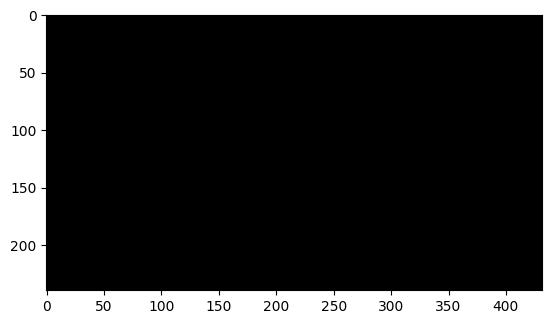

In [9]:


plt.imshow(gt_edges_bi[0][4][-1].cpu().squeeze().numpy(), cmap="gray")

In [10]:
gt_edges_bi[0][0][0]

tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]], device='cuda:0')

In [11]:
pred_flows_bi, pred_edges_bi = train_dataset.netG.forward_bidirect_flow(gt_flows_bi, local_masks)

AttributeError: 'TrainDataset' object has no attribute 'netG'

In [ ]:
import random

length = train_dataset.video_dict[train_dataset.video_names[0]]
sample_length = 10
num_ref_frame = train_dataset.num_ref_frames

complete_idx_set = list(range(length))
pivot = random.randint(0, length - sample_length)
local_idx = complete_idx_set[pivot : pivot + sample_length]
remain_idx = list(set(complete_idx_set) - set(local_idx))
ref_index = sorted(random.sample(remain_idx, num_ref_frame))

print("local_idx: ", local_idx)
print("remain_idx: ", remain_idx)
print("ref_index: ", ref_index)

local_idx:  [141, 142, 143, 144, 145, 146, 147, 148, 149, 150]
remain_idx:  [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179]
ref_index:  [3, 90, 175]
